# Imports

In [1]:
from pathlib import Path
from collections import Counter
import random
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
import pandas as pd

# Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# General configuration

In [3]:

CLASS_NAMES = [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "bus",
    "truck",
]

CLASS_ID_TO_NAME = {
    class_id: class_name
    for class_id, class_name in enumerate(CLASS_NAMES)
}

RANDOM_SEED = 42

# Directory where the figures and tables will be saved
OUTPUT_DIRECTORY = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations"
)

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIRECTORY)

Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations


# Annotaded image
### YOLO

In [4]:
SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
}


def find_images(image_directory):
    """
    Return all supported images contained in a directory,
    including its subdirectories.
    """
    image_directory = Path(image_directory)

    if not image_directory.exists():
        raise FileNotFoundError(
            f"Image directory not found: {image_directory}"
        )

    image_paths = sorted(
        path
        for path in image_directory.rglob("*")
        if path.is_file()
        and path.suffix.lower() in SUPPORTED_IMAGE_EXTENSIONS
    )

    return image_paths


def find_corresponding_label(
    image_path,
    image_directory,
    label_directory,
):
    """
    Find the YOLO label corresponding to an image while
    preserving any subdirectory structure.
    """
    image_path = Path(image_path)
    image_directory = Path(image_directory)
    label_directory = Path(label_directory)

    relative_path = image_path.relative_to(image_directory)

    label_path = (
        label_directory
        / relative_path
    ).with_suffix(".txt")

    return label_path


def read_yolo_annotations(label_path):
    """
    Read a YOLO annotation file.

    Expected format:
    class_id x_center y_center width height
    """
    label_path = Path(label_path)

    annotations = []

    if not label_path.exists():
        return annotations

    with open(label_path, "r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            values = line.strip().split()

            if not values:
                continue

            if len(values) < 5:
                print(
                    f"Warning: invalid annotation in "
                    f"{label_path}, line {line_number}"
                )
                continue

            try:
                class_id = int(float(values[0]))
                x_center = float(values[1])
                y_center = float(values[2])
                box_width = float(values[3])
                box_height = float(values[4])

            except ValueError:
                print(
                    f"Warning: unreadable annotation in "
                    f"{label_path}, line {line_number}"
                )
                continue

            annotations.append(
                {
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": box_width,
                    "height": box_height,
                }
            )

    return annotations

### Visualisation Function

In [5]:
def plot_annotated_image(
    image_path,
    label_path,
    dataset_name,
    save_directory,
):
    """
    Draw YOLO bounding boxes on an image and save the figure.
    """
    image_path = Path(image_path)
    label_path = Path(label_path)
    save_directory = Path(save_directory)

    image = Image.open(image_path).convert("RGB")
    image_width, image_height = image.size

    annotations = read_yolo_annotations(label_path)

    figure, axis = plt.subplots(figsize=(12, 7))

    axis.imshow(image)

    for annotation in annotations:
        class_id = annotation["class_id"]

        x_center = annotation["x_center"] * image_width
        y_center = annotation["y_center"] * image_height
        box_width = annotation["width"] * image_width
        box_height = annotation["height"] * image_height

        x_min = x_center - box_width / 2
        y_min = y_center - box_height / 2

        rectangle = Rectangle(
            (x_min, y_min),
            box_width,
            box_height,
            fill=False,
            linewidth=2,
        )

        axis.add_patch(rectangle)

        class_name = CLASS_ID_TO_NAME.get(
            class_id,
            f"class_{class_id}",
        )

        axis.text(
            x_min,
            max(0, y_min - 4),
            class_name,
            fontsize=9,
            bbox={
                "facecolor": "white",
                "alpha": 0.75,
                "edgecolor": "none",
                "pad": 2,
            },
        )

    axis.set_title(
        f"Sample annotated image from {dataset_name}",
        fontsize=14,
    )

    axis.axis("off")

    output_path = (
        save_directory
        / f"{dataset_name.lower()}_annotated_sample.png"
    )

    figure.tight_layout()
    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    print("Image:", image_path)
    print("Label:", label_path)
    print("Objects:", len(annotations))
    print("Saved to:", output_path)

    return output_path

### Choose an image

In [6]:
def select_representative_sample(
    image_directory,
    label_directory,
    minimum_objects=3,
    maximum_candidates=5000,
    seed=42,
):
    """
    Select a deterministic annotated sample with at least
    the requested number of objects.
    """
    image_directory = Path(image_directory)
    label_directory = Path(label_directory)

    image_paths = find_images(image_directory)

    if not image_paths:
        raise RuntimeError(
            f"No image found in: {image_directory}"
        )

    random_generator = random.Random(seed)
    random_generator.shuffle(image_paths)

    candidate_images = image_paths[:maximum_candidates]

    best_image_path = None
    best_label_path = None
    highest_object_count = -1

    for image_path in candidate_images:
        label_path = find_corresponding_label(
            image_path=image_path,
            image_directory=image_directory,
            label_directory=label_directory,
        )

        annotations = read_yolo_annotations(label_path)
        object_count = len(annotations)

        if object_count > highest_object_count:
            highest_object_count = object_count
            best_image_path = image_path
            best_label_path = label_path

        if object_count >= minimum_objects:
            return image_path, label_path

    if best_image_path is None:
        raise RuntimeError(
            "No image-label pair could be selected."
        )

    print(
        f"No sample contained {minimum_objects} objects. "
        f"Using the best available sample with "
        f"{highest_object_count} object(s)."
    )

    return best_image_path, best_label_path

# Class distribution

### Annotations count

In [7]:
def count_yolo_classes(label_directory):
    """
    Count the number of bounding boxes for every class.
    """
    label_directory = Path(label_directory)

    if not label_directory.exists():
        raise FileNotFoundError(
            f"Label directory not found: {label_directory}"
        )

    class_counter = Counter()
    label_file_count = 0
    empty_label_count = 0
    invalid_annotation_count = 0

    label_paths = sorted(label_directory.rglob("*.txt"))

    for label_path in label_paths:
        label_file_count += 1

        annotations = read_yolo_annotations(label_path)

        if not annotations:
            empty_label_count += 1
            continue

        for annotation in annotations:
            class_id = annotation["class_id"]

            if class_id in CLASS_ID_TO_NAME:
                class_counter[class_id] += 1
            else:
                invalid_annotation_count += 1

    class_distribution = pd.DataFrame(
        {
            "class_id": list(range(len(CLASS_NAMES))),
            "class_name": CLASS_NAMES,
            "object_count": [
                class_counter[class_id]
                for class_id in range(len(CLASS_NAMES))
            ],
        }
    )

    class_distribution["percentage"] = (
        class_distribution["object_count"]
        / max(class_distribution["object_count"].sum(), 1)
        * 100
    )

    summary = {
        "label_files": label_file_count,
        "empty_label_files": empty_label_count,
        "invalid_annotations": invalid_annotation_count,
        "total_objects": int(
            class_distribution["object_count"].sum()
        ),
    }

    return class_distribution, summary

# Distribution visualisation

In [8]:
def plot_class_distribution(
    class_distribution,
    dataset_name,
    save_directory,
):
    """
    Plot and save the class distribution.
    """
    save_directory = Path(save_directory)

    figure, axis = plt.subplots(figsize=(10, 6))

    bars = axis.bar(
        class_distribution["class_name"],
        class_distribution["object_count"],
    )

    axis.set_title(
        f"Object class distribution in {dataset_name}",
        fontsize=14,
    )

    axis.set_xlabel("Object class")
    axis.set_ylabel("Number of annotated objects")

    axis.tick_params(
        axis="x",
        rotation=30,
    )

    axis.grid(
        axis="y",
        alpha=0.25,
    )

    for bar, value in zip(
        bars,
        class_distribution["object_count"],
    ):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    figure.tight_layout()

    output_path = (
        save_directory
        / f"{dataset_name.lower()}_class_distribution.png"
    )

    figure.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    print("Saved to:", output_path)

    return output_path

# Statistic train, validation and test

### Split analysis

In [9]:
def analyse_dataset_split(
    dataset_name,
    split_name,
    image_directory,
    label_directory,
):
    """
    Produce summary statistics for one dataset split.
    """
    image_directory = Path(image_directory)
    label_directory = Path(label_directory)

    image_paths = find_images(image_directory)
    label_paths = sorted(label_directory.rglob("*.txt"))

    labelled_image_count = 0
    unlabelled_image_count = 0
    total_objects = 0

    image_widths = []
    image_heights = []

    for image_path in image_paths:
        label_path = find_corresponding_label(
            image_path=image_path,
            image_directory=image_directory,
            label_directory=label_directory,
        )

        annotations = read_yolo_annotations(label_path)

        if annotations:
            labelled_image_count += 1
            total_objects += len(annotations)
        else:
            unlabelled_image_count += 1

        try:
            with Image.open(image_path) as image:
                image_widths.append(image.width)
                image_heights.append(image.height)

        except Exception as error:
            print(
                f"Could not read image dimensions for "
                f"{image_path}: {error}"
            )

    image_count = len(image_paths)

    average_objects_per_image = (
        total_objects / image_count
        if image_count > 0
        else 0
    )

    average_width = (
        sum(image_widths) / len(image_widths)
        if image_widths
        else 0
    )

    average_height = (
        sum(image_heights) / len(image_heights)
        if image_heights
        else 0
    )

    return {
        "dataset": dataset_name,
        "split": split_name,
        "images": image_count,
        "label_files": len(label_paths),
        "images_with_objects": labelled_image_count,
        "images_without_objects": unlabelled_image_count,
        "objects": total_objects,
        "average_objects_per_image": average_objects_per_image,
        "average_width": average_width,
        "average_height": average_height,
    }

# **DAWN Analysis**

In [10]:
DAWN_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo"
)

DAWN_PATHS = {
    "train": {
        "images": DAWN_ROOT / "images/train",
        "labels": DAWN_ROOT / "labels/train",
    },
    "val": {
        "images": DAWN_ROOT / "images/val",
        "labels": DAWN_ROOT / "labels/val",
    },
    "test": {
        "images": DAWN_ROOT / "images/test",
        "labels": DAWN_ROOT / "labels/test",
    },
}

for split_name, paths in DAWN_PATHS.items():
    print(f"\n{split_name.upper()}")
    print("Images:", paths["images"])
    print("Labels:", paths["labels"])
    print("Images exist:", paths["images"].exists())
    print("Labels exist:", paths["labels"].exists())


TRAIN
Images: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/images/train
Labels: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/labels/train
Images exist: True
Labels exist: True

VAL
Images: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/images/val
Labels: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/labels/val
Images exist: True
Labels exist: True

TEST
Images: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/images/test
Labels: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/labels/test
Images exist: True
Labels exist: True


### Create annoted image DAWN

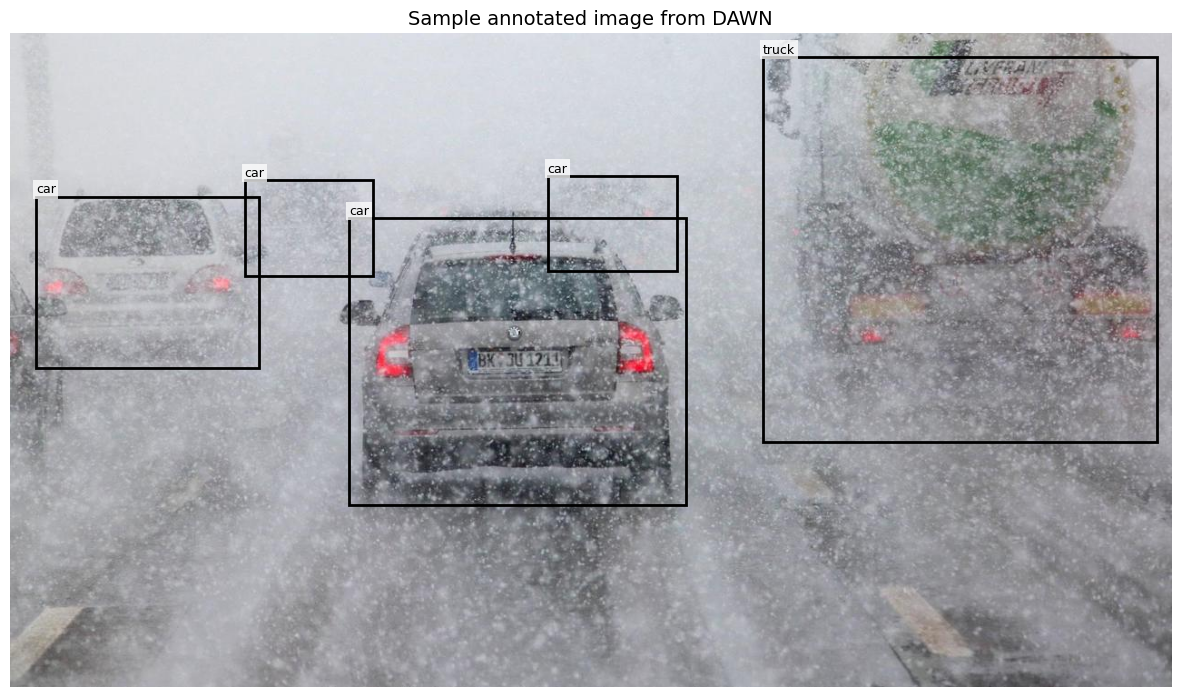

Image: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/images/test/snow_storm-225.jpg
Label: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/dawn_yolo/labels/test/snow_storm-225.txt
Objects: 5
Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/dawn_annotated_sample.png


In [11]:
dawn_sample_image, dawn_sample_label = (
    select_representative_sample(
        image_directory=DAWN_PATHS["test"]["images"],
        label_directory=DAWN_PATHS["test"]["labels"],
        minimum_objects=3,
        seed=RANDOM_SEED,
    )
)

dawn_annotated_figure = plot_annotated_image(
    image_path=dawn_sample_image,
    label_path=dawn_sample_label,
    dataset_name="DAWN",
    save_directory=OUTPUT_DIRECTORY,
)

## Distribution of classes (DAWN)

In [12]:
# Count each split separately
dawn_split_distributions = []

for split_name, paths in DAWN_PATHS.items():
    split_distribution, split_summary = count_yolo_classes(
        paths["labels"]
    )

    split_distribution = split_distribution.copy()
    split_distribution["split"] = split_name

    dawn_split_distributions.append(split_distribution)

    print(f"\nDAWN — {split_name}")
    print(split_summary)


DAWN — train
{'label_files': 423, 'empty_label_files': 0, 'invalid_annotations': 0, 'total_objects': 3358}

DAWN — val
{'label_files': 140, 'empty_label_files': 0, 'invalid_annotations': 0, 'total_objects': 1332}

DAWN — test
{'label_files': 140, 'empty_label_files': 0, 'invalid_annotations': 0, 'total_objects': 920}


In [13]:
# Combine train, validation and test counts
dawn_all_distributions = pd.concat(
    dawn_split_distributions,
    ignore_index=True,
)

dawn_class_distribution = (
    dawn_all_distributions
    .groupby(
        ["class_id", "class_name"],
        as_index=False,
    )["object_count"]
    .sum()
)

dawn_class_distribution["percentage"] = (
    dawn_class_distribution["object_count"]
    / dawn_class_distribution["object_count"].sum()
    * 100
)

display(dawn_class_distribution)

,class_id,class_name,object_count,percentage
0,0,person,303,5.401070
1,1,bicycle,17,0.303030
2,2,car,4706,83.885918
3,3,motorcycle,28,0.499109
4,4,bus,106,1.889483
5,5,truck,450,8.021390


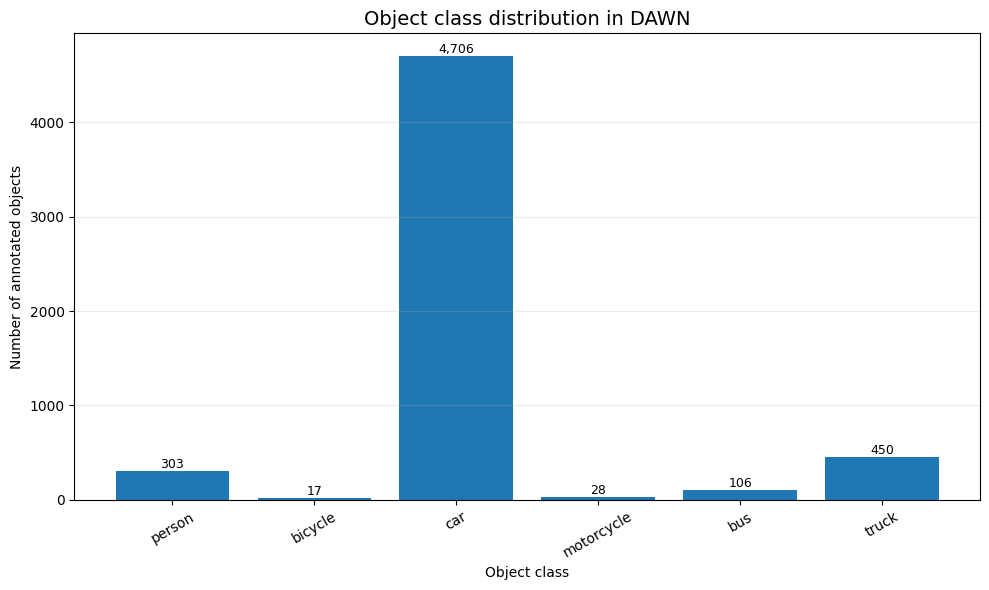

Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/dawn_class_distribution.png


In [14]:
dawn_distribution_figure = plot_class_distribution(
    class_distribution=dawn_class_distribution,
    dataset_name="DAWN",
    save_directory=OUTPUT_DIRECTORY,
)

In [15]:
dawn_class_distribution.to_csv(
    OUTPUT_DIRECTORY
    / "dawn_class_distribution.csv",
    index=False,
)

print("DAWN class distribution saved.")

DAWN class distribution saved.


In [17]:
def analyse_dataset_split(
    dataset_name,
    split_name,
    image_directory,
    label_directory,
):
    """
    Produce useful split statistics without opening image files.
    This is much faster when the dataset is stored on Google Drive.
    """
    image_directory = Path(image_directory)
    label_directory = Path(label_directory)

    if not image_directory.exists():
        raise FileNotFoundError(
            f"Image directory not found: {image_directory}"
        )

    if not label_directory.exists():
        raise FileNotFoundError(
            f"Label directory not found: {label_directory}"
        )

    image_paths = find_images(image_directory)
    label_paths = sorted(label_directory.rglob("*.txt"))

    images_with_objects = 0
    images_without_objects = 0
    total_objects = 0

    # Read the existing label files directly.
    for label_path in label_paths:
        with open(label_path, "r", encoding="utf-8") as file:
            valid_lines = [
                line
                for line in file
                if line.strip()
            ]

        object_count = len(valid_lines)
        total_objects += object_count

        if object_count > 0:
            images_with_objects += 1
        else:
            images_without_objects += 1

    image_count = len(image_paths)
    label_file_count = len(label_paths)

    # Images without a corresponding label file are also empty images.
    missing_label_count = max(
        image_count - label_file_count,
        0,
    )

    images_without_objects += missing_label_count

    average_objects_per_image = (
        total_objects / image_count
        if image_count > 0
        else 0
    )

    return {
        "dataset": dataset_name,
        "split": split_name,
        "images": image_count,
        "label_files": label_file_count,
        "images_with_objects": images_with_objects,
        "images_without_objects": images_without_objects,
        "objects": total_objects,
        "average_objects_per_image": round(
            average_objects_per_image,
            2,
        ),
    }

In [18]:
dawn_split_statistics = []

for split_name, paths in DAWN_PATHS.items():
    print(f"Analysing DAWN {split_name}...")

    statistics = analyse_dataset_split(
        dataset_name="DAWN",
        split_name=split_name,
        image_directory=paths["images"],
        label_directory=paths["labels"],
    )

    dawn_split_statistics.append(statistics)

dawn_statistics_table = pd.DataFrame(
    dawn_split_statistics
)

display(dawn_statistics_table)

Analysing DAWN train...
Analysing DAWN val...
Analysing DAWN test...


,dataset,split,images,label_files,images_with_objects,images_without_objects,objects,average_objects_per_image
0,DAWN,train,423,423,423,0,3358,7.94
1,DAWN,val,140,140,140,0,1332,9.51
2,DAWN,test,140,140,140,0,920,6.57


In [19]:
dawn_statistics_table.to_csv(
    OUTPUT_DIRECTORY
    / "dawn_split_statistics.csv",
    index=False,
)

print("DAWN split statistics saved.")

DAWN split statistics saved.


# **ACDC Analysis**

In [21]:
ACDC_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/acdc_yolo"
)

ACDC_PATHS = {
    "train": {
        "images": ACDC_ROOT / "images/train",
        "labels": ACDC_ROOT / "labels/train",
    },
    "val": {
        "images": ACDC_ROOT / "images/val",
        "labels": ACDC_ROOT / "labels/val",
    },
    "test": {
        "images": ACDC_ROOT / "images/test",
        "labels": ACDC_ROOT / "labels/test",
    },
}

### Annoted images

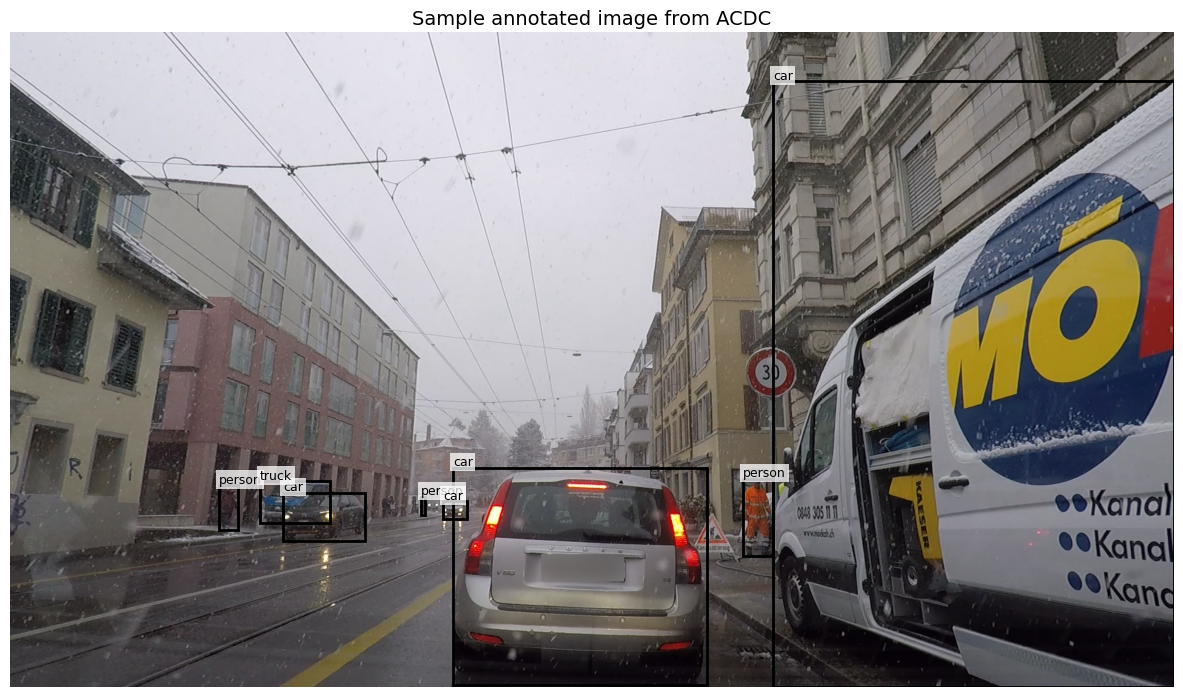

Image: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/acdc_yolo/images/test/rain_GOPR0607_frame_000246.jpg
Label: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/acdc_yolo/labels/test/rain_GOPR0607_frame_000246.txt
Objects: 8
Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/acdc_annotated_sample.png


In [22]:
acdc_sample_image, acdc_sample_label = (
    select_representative_sample(
        image_directory=ACDC_PATHS["test"]["images"],
        label_directory=ACDC_PATHS["test"]["labels"],
        minimum_objects=3,
        seed=RANDOM_SEED,
    )
)

acdc_annotated_figure = plot_annotated_image(
    image_path=acdc_sample_image,
    label_path=acdc_sample_label,
    dataset_name="ACDC",
    save_directory=OUTPUT_DIRECTORY,
)

### Classes distribution

In [23]:
acdc_split_distributions = []

for split_name, paths in ACDC_PATHS.items():

    split_distribution, split_summary = count_yolo_classes(
        paths["labels"]
    )

    split_distribution = split_distribution.copy()
    split_distribution["split"] = split_name

    acdc_split_distributions.append(split_distribution)

    print(f"\nACDC — {split_name}")
    print(split_summary)


ACDC — train
{'label_files': 1620, 'empty_label_files': 29, 'invalid_annotations': 0, 'total_objects': 10175}

ACDC — val
{'label_files': 540, 'empty_label_files': 5, 'invalid_annotations': 0, 'total_objects': 3333}

ACDC — test
{'label_files': 540, 'empty_label_files': 7, 'invalid_annotations': 0, 'total_objects': 3358}


In [24]:
acdc_all_distributions = pd.concat(
    acdc_split_distributions,
    ignore_index=True,
)

acdc_class_distribution = (
    acdc_all_distributions
    .groupby(
        ["class_id", "class_name"],
        as_index=False,
    )["object_count"]
    .sum()
)

acdc_class_distribution["percentage"] = (
    acdc_class_distribution["object_count"]
    / acdc_class_distribution["object_count"].sum()
    * 100
)

display(acdc_class_distribution)

,class_id,class_name,object_count,percentage
0,0,person,2842,16.850468
1,1,bicycle,569,3.373651
2,2,car,11702,69.382189
3,3,motorcycle,335,1.986245
4,4,bus,291,1.725365
5,5,truck,1127,6.682082


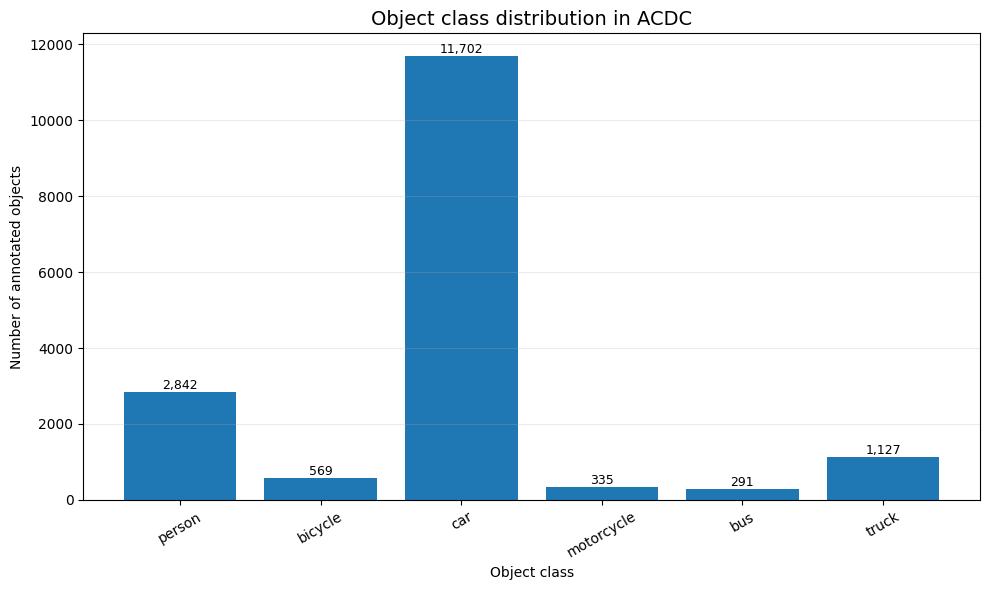

Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/acdc_class_distribution.png


In [25]:
plot_class_distribution(
    class_distribution=acdc_class_distribution,
    dataset_name="ACDC",
    save_directory=OUTPUT_DIRECTORY,
)

acdc_class_distribution.to_csv(
    OUTPUT_DIRECTORY / "acdc_class_distribution.csv",
    index=False,
)

### Statistic

In [26]:
acdc_split_statistics = []

for split_name, paths in ACDC_PATHS.items():

    print(f"Analysing {split_name}...")

    statistics = analyse_dataset_split(
        dataset_name="ACDC",
        split_name=split_name,
        image_directory=paths["images"],
        label_directory=paths["labels"],
    )

    acdc_split_statistics.append(statistics)

acdc_statistics_table = pd.DataFrame(
    acdc_split_statistics
)

display(acdc_statistics_table)

acdc_statistics_table.to_csv(
    OUTPUT_DIRECTORY / "acdc_split_statistics.csv",
    index=False,
)

Analysing train...
Analysing val...
Analysing test...


,dataset,split,images,label_files,images_with_objects,images_without_objects,objects,average_objects_per_image
0,ACDC,train,1620,1620,1591,29,10175,6.28
1,ACDC,val,540,540,535,5,3333,6.17
2,ACDC,test,540,540,533,7,3358,6.22


# **BDDK100 Analysis**

In [27]:
BDD100K_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo"
)

BDD100K_PATHS = {
    "train": {
        "images": BDD100K_ROOT / "images/train",
        "labels": BDD100K_ROOT / "labels/train",
    },
    "val": {
        "images": BDD100K_ROOT / "images/val",
        "labels": BDD100K_ROOT / "labels/val",
    },
}

for split_name, paths in BDD100K_PATHS.items():
    print(f"\n{split_name.upper()}")
    print("Images:", paths["images"])
    print("Labels:", paths["labels"])
    print("Images exist:", paths["images"].exists())
    print("Labels exist:", paths["labels"].exists())


TRAIN
Images: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/images/train
Labels: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/labels/train
Images exist: True
Labels exist: True

VAL
Images: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/images/val
Labels: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/labels/val
Images exist: True
Labels exist: True


### Anoted image

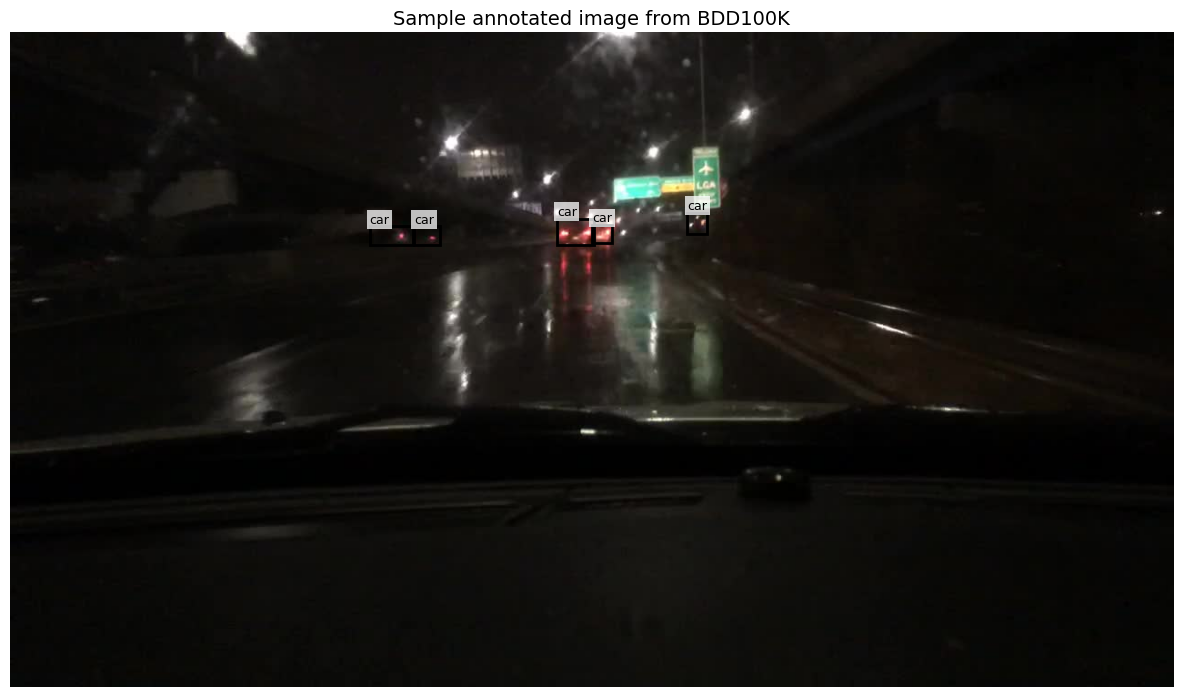

Image: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/images/val/b4715825-7c265849.jpg
Label: /content/drive/MyDrive/Colab Notebooks/Dissertation/Datasets/processed/BDD100K/yolo/labels/val/b4715825-7c265849.txt
Objects: 5
Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/bdd100k_annotated_sample.png


In [28]:
bdd_sample_image, bdd_sample_label = (
    select_representative_sample(
        image_directory=BDD100K_PATHS["val"]["images"],
        label_directory=BDD100K_PATHS["val"]["labels"],
        minimum_objects=3,
        seed=RANDOM_SEED,
    )
)

bdd_annotated_figure = plot_annotated_image(
    image_path=bdd_sample_image,
    label_path=bdd_sample_label,
    dataset_name="BDD100K",
    save_directory=OUTPUT_DIRECTORY,
)

### Distribution

In [29]:
bdd_split_distributions = []

for split_name, paths in BDD100K_PATHS.items():

    split_distribution, split_summary = count_yolo_classes(
        paths["labels"]
    )

    split_distribution = split_distribution.copy()
    split_distribution["split"] = split_name

    bdd_split_distributions.append(split_distribution)

    print(f"\nBDD100K — {split_name}")
    print(split_summary)


BDD100K — train
{'label_files': 10693, 'empty_label_files': 0, 'invalid_annotations': 0, 'total_objects': 122579}

BDD100K — val
{'label_files': 1504, 'empty_label_files': 0, 'invalid_annotations': 0, 'total_objects': 17733}


In [30]:
bdd_all_distributions = pd.concat(
    bdd_split_distributions,
    ignore_index=True,
)

bdd_class_distribution = (
    bdd_all_distributions
    .groupby(
        ["class_id", "class_name"],
        as_index=False,
    )["object_count"]
    .sum()
)

bdd_class_distribution["percentage"] = (
    bdd_class_distribution["object_count"]
    / bdd_class_distribution["object_count"].sum()
    * 100
)

display(bdd_class_distribution)

,class_id,class_name,object_count,percentage
0,0,person,15678,11.173670
1,1,bicycle,996,0.709847
2,2,car,115532,82.339358
3,3,motorcycle,269,0.191716
4,4,bus,2203,1.570072
5,5,truck,5634,4.015337


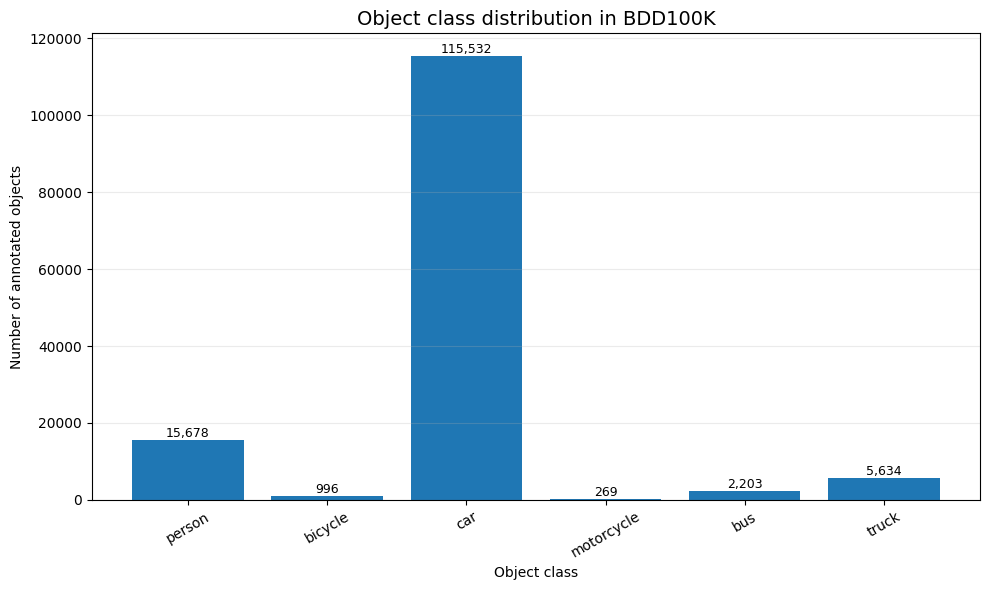

Saved to: /content/drive/MyDrive/Colab Notebooks/Dissertation/Dataset_Visualisations/bdd100k_class_distribution.png


In [31]:
plot_class_distribution(
    class_distribution=bdd_class_distribution,
    dataset_name="BDD100K",
    save_directory=OUTPUT_DIRECTORY,
)

bdd_class_distribution.to_csv(
    OUTPUT_DIRECTORY / "bdd100k_class_distribution.csv",
    index=False,
)

### Statistic

In [32]:
bdd_split_statistics = []

for split_name, paths in BDD100K_PATHS.items():

    print(f"Analysing {split_name}...")

    statistics = analyse_dataset_split(
        dataset_name="BDD100K",
        split_name=split_name,
        image_directory=paths["images"],
        label_directory=paths["labels"],
    )

    bdd_split_statistics.append(statistics)

bdd_statistics_table = pd.DataFrame(
    bdd_split_statistics
)

display(bdd_statistics_table)

bdd_statistics_table.to_csv(
    OUTPUT_DIRECTORY / "bdd100k_split_statistics.csv",
    index=False,
)

Analysing train...
Analysing val...


,dataset,split,images,label_files,images_with_objects,images_without_objects,objects,average_objects_per_image
0,BDD100K,train,10693,10693,10693,0,122579,11.46
1,BDD100K,val,1504,1504,1504,0,17733,11.79
